In [1]:

import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from collections import Counter

In [3]:

def read_docu(file):

    all_words = []

    with open(file, "r", encoding="utf-8") as input_file:
        for line in input_file:
            line = line.lower()
            line = line.strip().split()
            all_words += line
        return (all_words)

In [4]:
def word_counter(all_words):

    word_count = Counter()
    for word in all_words:
        word_count[word] += 1
    return (word_count.values())

In [5]:
def draw_zipfian_curve(word_count):
    plt.plot(sorted(word_count, reverse=True), marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("log(Rank)")
    plt.ylabel("log(Frequency)")
    plt.show()

In [6]:
def zipfian_plot(file):
    word_corpus = read_docu(file)
    counts = word_counter(word_corpus)
    draw_zipfian_curve(counts)

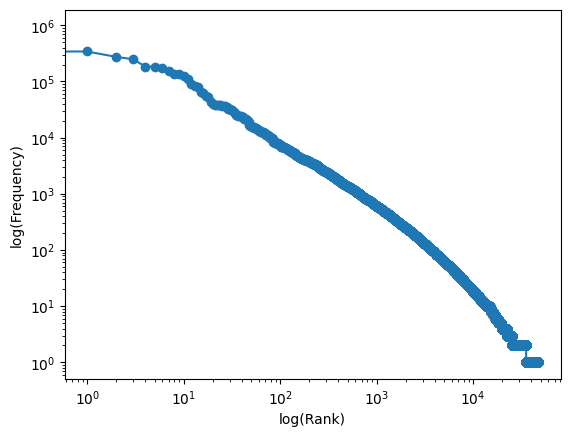

In [7]:
zipfian_plot("train_snli.txt")

In [8]:
df = pd.read_csv('train_snli.txt', sep='\t', names=['person', 'omelette','output'])
df.head()

,person,omelette,output
0,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",0
1,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",1
2,Children smiling and waving at camera,There are children present,1
3,Children smiling and waving at camera,The kids are frowning,0
4,A boy is jumping on skateboard in the middle o...,The boy skates down the sidewalk.,0


In [9]:
df.isnull().sum()

person      0
omelette    4
output      0
dtype: int64

In [10]:
text = "Two blond women are hugging one another"

print("length of text: ", len(text))

splitted_text = text.split()  
print("Splitted text: ", splitted_text)

length of text:  39
Splitted text:  ['Two', 'blond', 'women', 'are', 'hugging', 'one', 'another']


In [11]:
specific_words = [word for word in splitted_text if (len(word) > 2)]
print("Words which are more than 3 letter: ", specific_words)

capital_words = [word for word in splitted_text if word.istitle()]
print("Capitalized words: ", capital_words)

words_end_with_o = [word for word in splitted_text if word.endswith("o")]
print("words end with o: ", words_end_with_o)

words_start_with_w = [word for word in splitted_text if word.startswith("w")]
print("words start with w: ", words_start_with_w) 

Words which are more than 3 letter:  ['Two', 'blond', 'women', 'are', 'hugging', 'one', 'another']
Capitalized words:  ['Two']
words end with o:  ['Two']
words start with w:  ['women']


In [12]:

print("unique words: ", set(splitted_text))

lowercase_text = [word.lower() for word in splitted_text]

print("unique words: ", set(lowercase_text))

unique words:  {'hugging', 'blond', 'Two', 'another', 'women', 'one', 'are'}
unique words:  {'hugging', 'blond', 'two', 'another', 'women', 'one', 'are'}


In [13]:
f = open("train_snli.txt", "r")

# read first line
print(f.readline())

# length of text
text3 = f.read()
print("Length of text: ", len(text3))

# Number of lines with splitlines() method
lines = text3.splitlines()
print("Number of lines: ", len(lines))

A person on a horse jumps over a broken down airplane.	A person is at a diner, ordering an omelette.	0

Length of text:  38743027
Number of lines:  367372


In [14]:
df.head()

,person,omelette,output
0,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",0
1,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",1
2,Children smiling and waving at camera,There are children present,1
3,Children smiling and waving at camera,The kids are frowning,0
4,A boy is jumping on skateboard in the middle o...,The boy skates down the sidewalk.,0


In [15]:
import nltk as nlp
# nlp.download('wordnet')
# nlp.download('omw-1.4')
# nlp.download('punkt_tab')

text = df.person[1]
splitted = text.split(" ")
print("number of words: ", len(splitted))

text = df.person[1]
print("number of unique words: ", len(set(splitted)))

print("first 5 unique words: ", list(set(splitted))[:5])

dist = nlp.FreqDist(splitted)
print("frequency of words: ", dist)

print("words in person: ", dist.keys())

print("the word box is occured how many times:", dist["box"])

number of words:  11
number of unique words:  10
first 5 unique words:  ['airplane.', 'person', 'A', 'broken', 'horse']
frequency of words:  <FreqDist with 10 samples and 11 outcomes>
words in person:  dict_keys(['A', 'person', 'on', 'a', 'horse', 'jumps', 'over', 'broken', 'down', 'airplane.'])
the word box is occured how many times: 0


In [16]:
# normalization
words = "task Tasked tasks tasking"
words_list = words.lower().split(" ")
print("normalized words: ", words_list)

# stemming
porter_stemmer = nlp.PorterStemmer()
roots = [porter_stemmer.stem(each) for each in words_list]
print("roots of task Tasked tasks tasking: ", roots)

normalized words:  ['task', 'tasked', 'tasks', 'tasking']
roots of task Tasked tasks tasking:  ['task', 'task', 'task', 'task']


In [17]:
df = pd.read_csv('train_snli.txt', sep='\t', names=['person', 'omelette','output'])
df.head()

,person,omelette,output
0,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",0
1,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",1
2,Children smiling and waving at camera,There are children present,1
3,Children smiling and waving at camera,The kids are frowning,0
4,A boy is jumping on skateboard in the middle o...,The boy skates down the sidewalk.,0


In [18]:
# stemming
stemming_word_list = ["baseball", "airplane",
                      "restaurant", "drinking", "outdoors"]
porter_stemmer = nlp.PorterStemmer()
roots = [porter_stemmer.stem(each) for each in stemming_word_list]
print("result of stemming: ", roots)

# lemmatization
lemma = nlp.WordNetLemmatizer()
lemma_roots = [lemma.lemmatize(each) for each in stemming_word_list]
print("result of lemmatization: ", lemma_roots)

result of stemming:  ['basebal', 'airplan', 'restaur', 'drink', 'outdoor']
result of lemmatization:  ['baseball', 'airplane', 'restaurant', 'drinking', 'outdoors']


In [19]:
text_t = "Two groups of rival gang members flipped each other off."
print("split the sentence: ", text_t.split(" "))  # 5 words

# tokenization with nltk
print("tokenize with nltk: ", nlp.word_tokenize(text_t))

split the sentence:  ['Two', 'groups', 'of', 'rival', 'gang', 'members', 'flipped', 'each', 'other', 'off.']
tokenize with nltk:  ['Two', 'groups', 'of', 'rival', 'gang', 'members', 'flipped', 'each', 'other', 'off', '.']


In [20]:
# categorical features with missing values
categorical_nan = [feature for feature in df.columns if df[feature].isna(
).sum() > 0 and df[feature].dtypes == 'O']
print(categorical_nan)

['omelette']


In [21]:
# replacing missing values in categorical features
for feature in categorical_nan:
    df[feature] = df[feature].fillna('None')

In [22]:
df[categorical_nan].isna().sum()

omelette    0
dtype: int64

In [23]:
from sklearn.feature_extraction.text import CountVectorizer  # for bag of words
max_features = 150  # max_features dimension reduction
count_vectorizer = CountVectorizer(
    stop_words="english", max_features=max_features)
review_list = df.iloc[:, 1]

# stop_words parameter = automatically remove all stopwords
# lowercase parameter
# token_pattern removing other karakters like .. !

# sparce matrix yaratir bag of words model = sparce matrix
sparce_matrix = count_vectorizer.fit_transform(review_list)

print("Most used {} words: {}".format(
    max_features, count_vectorizer.get_feature_names_out()))

y = df.iloc[:, 0].values  # positive or negative comment

# sparce matrix includes independent variable

Most used 150 words: ['air' 'animal' 'asleep' 'baby' 'ball' 'band' 'baseball' 'basketball'
 'beach' 'bed' 'bench' 'bike' 'black' 'blue' 'boat' 'boy' 'boys' 'brown'
 'building' 'bus' 'camera' 'car' 'carrying' 'cat' 'child' 'children'
 'city' 'climbing' 'clothes' 'couch' 'couple' 'crowd' 'dancing' 'dog'
 'dogs' 'doing' 'dress' 'dressed' 'drinking' 'driving' 'eating' 'female'
 'field' 'food' 'football' 'game' 'getting' 'girl' 'girls' 'going' 'grass'
 'green' 'ground' 'group' 'guitar' 'guy' 'guys' 'hair' 'hands' 'hat'
 'having' 'holding' 'holds' 'home' 'horse' 'house' 'human' 'indoors'
 'inside' 'jacket' 'jumping' 'jumps' 'kid' 'kids' 'lady' 'lake' 'large'
 'laying' 'little' 'looking' 'looks' 'making' 'man' 'men' 'music' 'near'
 'ocean' 'old' 'outdoors' 'outside' 'park' 'people' 'performing' 'person'
 'picture' 'play' 'player' 'players' 'playing' 'plays' 'pool' 'race'
 'reading' 'red' 'restaurant' 'rides' 'riding' 'road' 'room' 'running'
 'runs' 'shirt' 'sidewalk' 'sit' 'sits' 'sitting' 's

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(sparce_matrix, y,test_size = 0.1,random_state = 0)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(x_train, y_train)
print("Test accuracy:", nb.score(x_test, y_test))

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = nb.predict(sparce_matrix)
cm = confusion_matrix(y,y_pred)
cm

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt='.1f', ax=ax)
plt.show()
plt.savefig('graph.png')